In [4]:
%pip install scikit-learn
import numpy as np 
import pandas as pd 
from sklearn.datasets import fetch_openml

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False
)

X = mnist.data
y = mnist.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Note: you may need to restart the kernel to use updated packages.
Features shape: (70000, 784)
Target shape: (70000,)


In [5]:
X = X[:5000]
y = y[:5000]

print(X.shape)

(5000, 784)


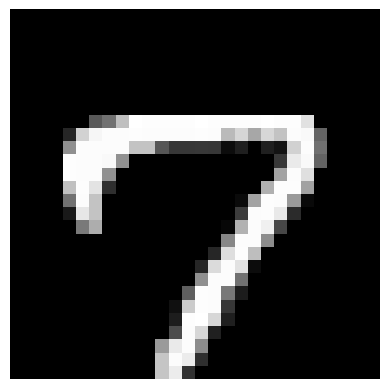

In [11]:
df = pd.DataFrame(X)
df['label'] = y
import matplotlib.pyplot as plt
# Convert pixel values to numeric
image = df.iloc[1306, :-1].astype(float).values

# Convert 784 pixels → 28 × 28 image
image = image.reshape(28, 28)

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

In [16]:
X_test_scaled = scaler.transform(X_test)

In [17]:
pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

print("After PCA:")
print("Training:", X_train_pca.shape)
print("Testing:", X_test_pca.shape)


After PCA:
Training: (4000, 50)
Testing: (1000, 50)


In [18]:
print(
    "Variance explained:",
    pca.explained_variance_ratio_.sum()
)

Variance explained: 0.621311120011866


In [19]:
knn = KNeighborsClassifier(
    n_neighbors=5
)
knn.fit(
    X_train_pca,
    y_train
)

y_pred = knn.predict(X_test_pca)
accuracy = accuracy_score(
    y_test,
    y_pred
)
print("Accuracy:", accuracy)
print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.925
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        96
           1       0.96      0.97      0.96       113
           2       0.89      0.87      0.88        97
           3       0.89      0.94      0.92        99
           4       0.92      0.96      0.94       107
           5       0.95      0.83      0.88        87
           6       0.97      1.00      0.99       100
           7       0.89      0.91      0.90       110
           8       0.92      0.89      0.91        92
           9       0.91      0.87      0.89        99

    accuracy                           0.93      1000
   macro avg       0.93      0.92      0.92      1000
weighted avg       0.93      0.93      0.92      1000



In [20]:
from sklearn.decomposition import PCA

# Transforming data to a 2D coordinate system
pca = PCA(n_components=2)

# Fit PCA only on training data and transform it
X_train_trf = pca.fit_transform(X_train)

# Transform test data using the same PCA
X_test_trf = pca.transform(X_test)

X_train_trf

array([[1088.13226808, -236.68319575],
       [ 438.33364393,    6.59071133],
       [-883.91561048,  308.67070431],
       ...,
       [-802.74022361,  -48.22953513],
       [ 166.64393358, -585.0552921 ],
       [1548.55611317,  127.57301103]], shape=(4000, 2))

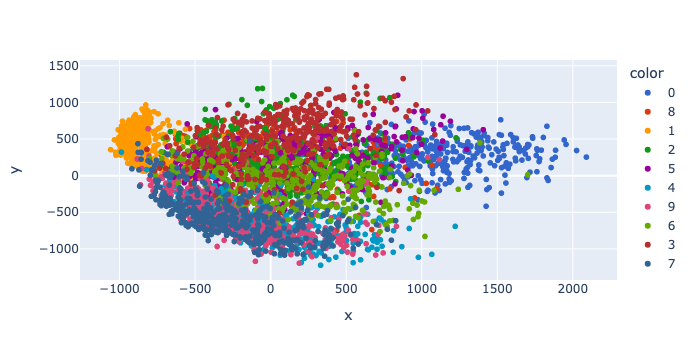

In [21]:
import plotly.express as px

# Convert labels to string so that they are treated as categories
y_train_trf = y_train.astype(str)

fig = px.scatter(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()

In [22]:
# Transforming data to a 3D coordinate system
pca = PCA(n_components=3)

X_train_trf = pca.fit_transform(X_train)

X_test_trf = pca.transform(X_test)

X_train_trf

array([[1088.12844778, -236.67096166,  685.65933338],
       [ 438.33421195,    6.59148632,  319.85259198],
       [-883.9157493 ,  308.67116093,   54.9795378 ],
       ...,
       [-802.73762376,  -48.23249299, -245.98537188],
       [ 166.6397327 , -585.05282319,  234.85719425],
       [1548.5544308 ,  127.56754558, -999.43554029]], shape=(4000, 3))

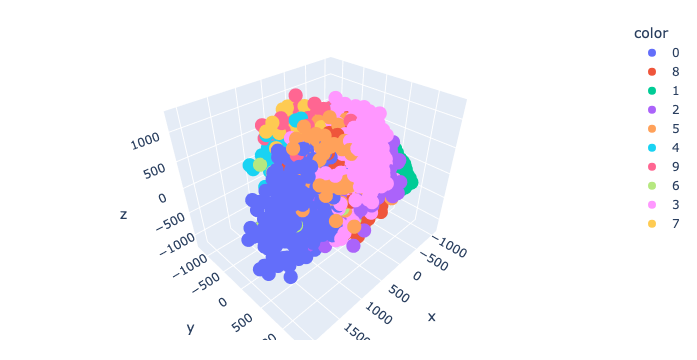

In [23]:
y_train_trf = y_train.astype(str)

fig = px.scatter_3d(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    z=X_train_trf[:, 2],
    color=y_train_trf,
)

fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20)
)

fig.show()

In [24]:

# STEP 1 — Find cumulative explained variance

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA with all components
# MNIST mein maximum components = 784
pca = PCA()

# Fit PCA on training data
pca.fit(X_train)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print("Cumulative variance:")
print(cumulative_variance)

Cumulative variance:
[0.09861079 0.1721643  0.23321367 0.28784652 0.33499586 0.37906328
 0.41244309 0.44201563 0.46996031 0.4930075  0.51462181 0.53486275
 0.55219404 0.56869827 0.58482291 0.60029851 0.61318494 0.62560089
 0.63766261 0.64913973 0.65969105 0.66948978 0.67912251 0.68852688
 0.69732409 0.70586718 0.71390737 0.72150449 0.72891259 0.73583465
 0.74260904 0.74880416 0.75480726 0.76063576 0.76612157 0.77148582
 0.77660011 0.7815043  0.78630897 0.79102524 0.79549561 0.7997299
 0.80387821 0.80790462 0.81173268 0.8154471  0.81901931 0.82251777
 0.82595626 0.82919776 0.83235076 0.83548671 0.83855425 0.84151272
 0.84433447 0.84709766 0.84974751 0.85231159 0.85479095 0.85723406
 0.85958556 0.86191243 0.86418849 0.86639792 0.86853258 0.87059429
 0.87262837 0.87460795 0.87654981 0.87846383 0.88032958 0.88208621
 0.88380092 0.88551224 0.8871561  0.88878497 0.89037128 0.89187397
 0.89334774 0.89480594 0.89622347 0.89761767 0.89897893 0.90032365
 0.90163343 0.90292594 0.9041765  0.905410

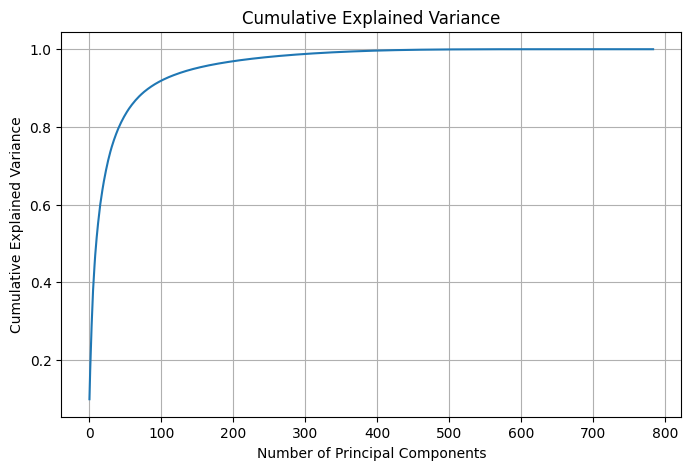

In [25]:
# STEP 2 — Plot cumulative explained variance

plt.figure(figsize=(8, 5))

plt.plot(cumulative_variance)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance")

plt.grid()

plt.show()

In [26]:
# STEP 3 — Find number of PCs for 90% and 95% variance
# np.argmax gives the first position where condition becomes True

n_components_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("Components needed for 90% variance:",
      n_components_90)

print("Components needed for 95% variance:",
      n_components_95)

Components needed for 90% variance: 84
Components needed for 95% variance: 147


In [27]:
# STEP 4 — PCA keeping 95% variance
# Instead of specifying number of components,
# give the required variance directly.

pca = PCA(n_components=0.95)

X_train_trf = pca.fit_transform(X_train)

X_test_trf = pca.transform(X_test)

print("Original number of features:",
      X_train.shape[1])

print("New number of features:",
      X_train_trf.shape[1])

print("Variance retained:",
      pca.explained_variance_ratio_.sum())

Original number of features: 784
New number of features: 147
Variance retained: 0.9500379078350828
